In [1]:
from pandas import DataFrame
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score


def greedy_matching(record_df: DataFrame):
    sorted_df = record_df.sort_values(
        by=["score", "old_index", "index_sim"], ascending=(False, True, True)
    )
    matched_pairs, used_old, used_new = list(), set(), set()

    for _, row in sorted_df.iterrows():
        o_idx, n_idx = row["old_index"], row["new_index"]
        if o_idx not in used_old and n_idx not in used_new:
            matched_pairs.append((o_idx, n_idx, row["score"]))
            used_old.add(o_idx)
            used_new.add(n_idx)

    return matched_pairs


def match(df: DataFrame):
    matched_df = df.copy()
    matched_pairs_all = []
    for record_id, record_df in matched_df.groupby("record_id"):
        matched_pairs = greedy_matching(record_df)
        for p in matched_pairs:
            matched_pairs_all.append([record_id, p[0], p[1]])

    keys = ["record_id", "old_index", "new_index"]

    # create a new column indicating greedy matched pairs
    mask = matched_df[keys].apply(list, axis=1).isin(matched_pairs_all)
    matched_df["matched"] = False
    matched_df.loc[mask, "matched"] = True
    return matched_df


def classify_by_thresh(
    matched_df: DataFrame, thresh: float, validation_fail_pairs: DataFrame | None = None
):
    res = matched_df.copy()

    # create a new column indicating classification results based on the threshold
    res["pred"] = 0
    mask2 = res["matched"] & (res["score"] > thresh)
    res.loc[mask2, "pred"] = 1

    # if phantom api pairs are given, set corresponding results to 0
    keys = ["record_id", "old_index", "new_index"]
    if validation_fail_pairs is not None:
        idx1 = pd.MultiIndex.from_frame(res[keys])
        idx2 = pd.MultiIndex.from_frame(validation_fail_pairs)
        mask3 = idx1.isin(idx2)
        res["phantom"] = False
        res.loc[mask3, "phantom"] = True
        res.loc[mask3, "pred"] = 0
    return res


def calculate_f1(df: DataFrame):
    p = precision_score(df["label"], df["pred"], zero_division=1.0)
    r = recall_score(df["label"], df["pred"])
    f1 = f1_score(df["label"], df["pred"])
    return f1, p, r

In [2]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import GroupKFold
from itertools import product


def single_kfold(
    df, folds, params, feature_cols, phantom_pairs: DataFrame | None = None
):
    total_test_f1 = 0.0
    for train_idx, test_idx in folds:
        train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
        train_df["score"] = sum(
            train_df[feature_cols[i]] * params[i] for i in range(len(feature_cols))
        )
        train_df["index_sim"] = abs(train_df["new_index"] - train_df["old_index"])

        best_thresh = None
        best_train_f1 = 0.0
        for thresh in np.linspace(0.0, 1.0, 21):
            matched_train_df = match(train_df)
            train_f1, _, _ = calculate_f1(
                classify_by_thresh(matched_train_df, thresh, phantom_pairs)
            )
            if train_f1 >= best_train_f1:
                best_train_f1 = train_f1
                best_thresh = thresh

        test_df["score"] = sum(
            test_df[feature_cols[i]] * params[i] for i in range(len(feature_cols))
        )
        test_df["index_sim"] = abs(test_df["new_index"] - test_df["old_index"])
        matched_test_df = match(test_df)
        test_f1, _, _ = calculate_f1(
            classify_by_thresh(matched_test_df, best_thresh, phantom_pairs)
        )
        total_test_f1 += test_f1
    return params, total_test_f1 / len(folds)


def tune_model_kfold(df, feature_cols, phantom_pairs: DataFrame | None = None):
    """Finds the best hyperparameters/weights using a sub-split of the training data."""
    # 1. Define Search Space
    num_features = len(feature_cols)
    step = 0.1
    scale = int(1 / step)
    param_grid = [
        [_ * step for _ in w]
        for w in product(range(1, scale + 1), repeat=num_features)
        if sum(w) == scale
    ]
    print(f"{len(param_grid)} weight confgurations")

    # 2. Grid Search with K-fold cross validation
    gkf = GroupKFold(n_splits=5)
    folds = list(gkf.split(df, groups=df["record_id"]))
    n_jobs = 128 if len(param_grid) > 128 else len(param_grid)
    res = Parallel(n_jobs=n_jobs)(
        delayed(single_kfold)(df, folds, params, feature_cols, phantom_pairs)
        for params in tqdm(param_grid)
    )
    return sorted(res, key=lambda r: r[-1], reverse=True)

In [3]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np
from itertools import product


def single_all(df, params, feature_cols, phantom_pairs: DataFrame | None = None):
    tmp = df.copy()
    tmp["score"] = sum(
        tmp[feature_cols[i]] * params[i] for i in range(len(feature_cols))
    )
    tmp["index_sim"] = abs(tmp["new_index"] - tmp["old_index"])
    best_f1 = 0.0
    for thresh in np.linspace(0.0, 1.0, 21):
        matched_tmp = match(tmp)
        f1, _, _ = calculate_f1(classify_by_thresh(matched_tmp, thresh, phantom_pairs))
        if f1 >= best_f1:
            best_f1 = f1
    return params, best_f1


def tune_model_all(df, feature_cols, phantom_pairs: DataFrame | None = None):
    """Finds the best hyperparameters/weights using a sub-split of the training data."""
    # 1. Define Search Space
    num_features = len(feature_cols)
    step = 0.1
    scale = int(1 / step)
    param_grid = [
        [_ * step for _ in w]
        for w in product(range(1, scale + 1), repeat=num_features)
        if sum(w) == scale
    ]
    print(f"{len(param_grid)} weight confgurations")

    # 2. Grid Search with K-fold cross validation
    n_jobs = 128 if len(param_grid) > 128 else len(param_grid)
    res = Parallel(n_jobs=n_jobs)(
        delayed(single_all)(df, params, feature_cols, phantom_pairs)
        for params in tqdm(param_grid)
    )
    return sorted(res, key=lambda r: r[-1], reverse=True)

In [5]:
import pandas as pd

py_df = pd.read_csv("../benchmark/ground_truth/py_ground_truth.csv")
py_feature_cols = ["fqn_sim", "arg_sim"]
py_validation_fail_api_pairs = pd.read_csv(
    "../benchmark/ground_truth/py_validation_results.csv"
)
py_validation_fail_api_pairs = py_validation_fail_api_pairs[
    ~py_validation_fail_api_pairs["validation"]
][["record_id", "old_index", "new_index"]]
py_res_kfold = tune_model_kfold(py_df, py_feature_cols)
py_res_phantom_kfold = tune_model_kfold(
    py_df, py_feature_cols, py_validation_fail_api_pairs
)
py_res_all = tune_model_all(py_df, py_feature_cols)
py_res_phantom_all = tune_model_all(
    py_df, py_feature_cols, py_validation_fail_api_pairs
)

9 weight confgurations


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 69.09it/s]


9 weight confgurations


100%|██████████| 9/9 [00:00<00:00, 5019.11it/s]


9 weight confgurations


100%|██████████| 9/9 [00:00<00:00, 933.34it/s]


9 weight confgurations


100%|██████████| 9/9 [00:00<00:00, 5052.03it/s]


In [6]:
py_res_kfold[:5], py_res_all[:5]

([([0.8, 0.2], 0.6387122858362073),
  ([0.6000000000000001, 0.4], 0.6366987530836187),
  ([0.7000000000000001, 0.30000000000000004], 0.6311821164660852),
  ([0.4, 0.6000000000000001], 0.6274526885690739),
  ([0.9, 0.1], 0.6252816557042303)],
 [([0.7000000000000001, 0.30000000000000004], 0.6492659053833605),
  ([0.8, 0.2], 0.6481178396072013),
  ([0.6000000000000001, 0.4], 0.6472491909385113),
  ([0.9, 0.1], 0.643312101910828),
  ([0.4, 0.6000000000000001], 0.6361974405850092)])

In [7]:
py_res_phantom_kfold[:5], py_res_phantom_all[:5]

([([0.6000000000000001, 0.4], 0.7315758940758941),
  ([0.8, 0.2], 0.7282780160956204),
  ([0.9, 0.1], 0.7282780160956204),
  ([0.4, 0.6000000000000001], 0.7271883904914737),
  ([0.5, 0.5], 0.7253736731337022)],
 [([0.5, 0.5], 0.7447306791569087),
  ([0.6000000000000001, 0.4], 0.7441860465116279),
  ([0.4, 0.6000000000000001], 0.7435294117647059),
  ([0.8, 0.2], 0.7414187643020596),
  ([0.9, 0.1], 0.7414187643020596)])

In [8]:
java_df = pd.read_csv("../benchmark/ground_truth/java_ground_truth.csv")
java_feature_cols = ["class_sim", "method_sim", "arg_sim"]
java_validation_fail_api_pairs = pd.read_csv(
    "../benchmark/ground_truth/java_validation_results.csv"
)
java_validation_fail_api_pairs = java_validation_fail_api_pairs[
    ~java_validation_fail_api_pairs["validation"]
][["record_id", "old_index", "new_index"]]
java_res_kfold = tune_model_kfold(java_df, java_feature_cols)
java_res_phantom_kfold = tune_model_kfold(
    java_df, java_feature_cols, java_validation_fail_api_pairs
)
java_res_all = tune_model_all(java_df, java_feature_cols)
java_res_phantom_all = tune_model_all(
    java_df, java_feature_cols, java_validation_fail_api_pairs
)

36 weight confgurations


100%|██████████| 36/36 [00:00<00:00, 66.56it/s]


36 weight confgurations


100%|██████████| 36/36 [00:00<00:00, 4929.32it/s]


36 weight confgurations


100%|██████████| 36/36 [00:00<00:00, 15031.85it/s]


36 weight confgurations


100%|██████████| 36/36 [00:00<00:00, 13252.15it/s]


In [9]:
java_res_kfold[:5], java_res_all[:5]

([([0.4, 0.5, 0.1], 0.7194108051617868),
  ([0.4, 0.4, 0.2], 0.7171265826904925),
  ([0.30000000000000004, 0.4, 0.30000000000000004], 0.7156532286023453),
  ([0.30000000000000004, 0.30000000000000004, 0.4], 0.715067049189577),
  ([0.1, 0.4, 0.5], 0.7093822987256758)],
 [([0.4, 0.5, 0.1], 0.7194444444444444),
  ([0.4, 0.4, 0.2], 0.717032967032967),
  ([0.30000000000000004, 0.4, 0.30000000000000004], 0.7154929577464789),
  ([0.30000000000000004, 0.30000000000000004, 0.4], 0.7146814404432132),
  ([0.1, 0.5, 0.4], 0.7121212121212122)])

In [10]:
java_res_phantom_kfold[:5], java_res_phantom_all[:5]

([([0.30000000000000004, 0.5, 0.2], 0.8957812002604835),
  ([0.4, 0.30000000000000004, 0.30000000000000004], 0.8950449971494004),
  ([0.2, 0.6000000000000001, 0.2], 0.8938851305437728),
  ([0.30000000000000004, 0.4, 0.30000000000000004], 0.893498782130837),
  ([0.2, 0.30000000000000004, 0.5], 0.8893518651179637)],
 [([0.4, 0.30000000000000004, 0.30000000000000004], 0.9),
  ([0.30000000000000004, 0.5, 0.2], 0.8979591836734694),
  ([0.30000000000000004, 0.4, 0.30000000000000004], 0.8967551622418879),
  ([0.2, 0.6000000000000001, 0.2], 0.8956521739130435),
  ([0.2, 0.5, 0.30000000000000004], 0.8934306569343066)])

0.0: 0.7951219512195122 0.6735537190082644 0.7293064876957495
0.05: 0.7951219512195122 0.6735537190082644 0.7293064876957495
0.1: 0.7951219512195122 0.6735537190082644 0.7293064876957495
0.15000000000000002: 0.8029556650246306 0.6735537190082644 0.7325842696629213
0.2: 0.8307692307692308 0.6694214876033058 0.7414187643020596
0.25: 0.8594594594594595 0.6570247933884298 0.7447306791569087
0.30000000000000004: 0.8594594594594595 0.6570247933884298 0.7447306791569087
0.35000000000000003: 0.8857142857142857 0.640495867768595 0.7434052757793765
0.4: 0.8850574712643678 0.6363636363636364 0.7403846153846154
0.45: 0.8830409356725146 0.6239669421487604 0.7312348668280871
0.5: 0.8723404255319149 0.5082644628099173 0.6422976501305483
0.55: 0.8913043478260869 0.5082644628099173 0.6473684210526316
0.6000000000000001: 0.8939393939393939 0.48760330578512395 0.6310160427807486
0.65: 0.9105691056910569 0.4628099173553719 0.6136986301369863
0.7000000000000001: 0.9067796610169492 0.44214876033057854 0.594

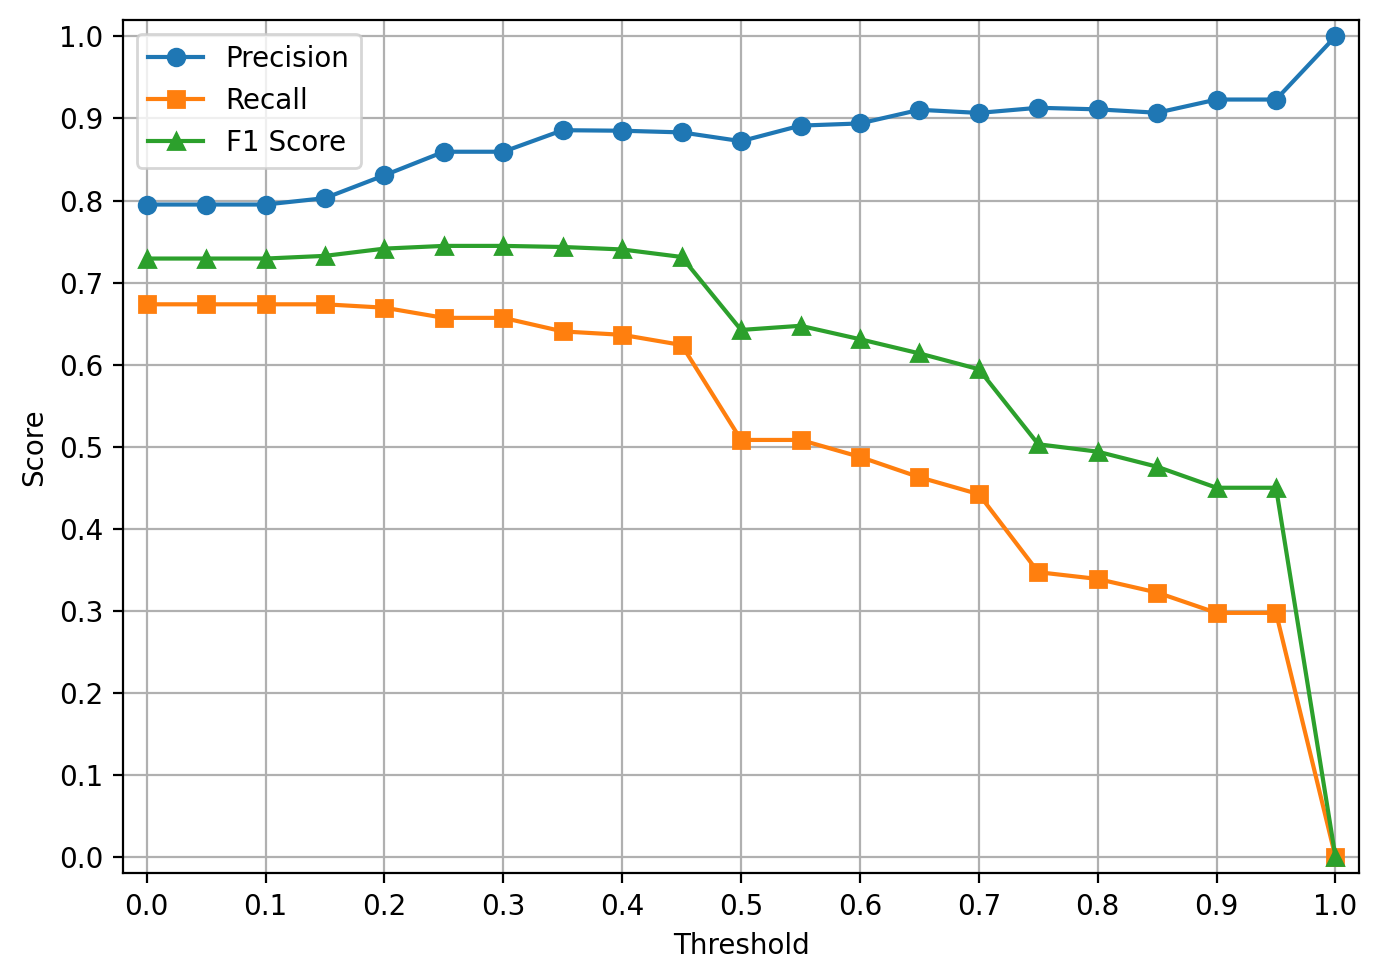

In [12]:
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_formats="retina"


def pr_curve(lang: str, feature_cols: list[str], params: list[float]):
    df = pd.read_csv(f"../benchmark/ground_truth/{lang}_ground_truth.csv")
    phantom_pairs = None
    phantom_pairs = pd.read_csv(
        f"../benchmark/ground_truth/{lang}_validation_results.csv"
    )
    phantom_pairs = phantom_pairs[~phantom_pairs["validation"]][
        ["record_id", "old_index", "new_index"]
    ]
    df["score"] = sum(df[feature_cols[i]] * params[i] for i in range(len(feature_cols)))
    df["index_sim"] = abs(df["old_index"] - df["new_index"])
    matched_df = match(df)
    precisions, recalls, thresholds, f1s = [], [], [], []
    for thresh in np.linspace(0.0, 1.0, 21):
        f1, p, r = calculate_f1(classify_by_thresh(matched_df, thresh, phantom_pairs))
        print(f"{thresh}: {p} {r} {f1}")
        thresholds.append(thresh)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(thresholds, precisions, label="Precision", marker="o")
    ax.plot(thresholds, recalls, label="Recall", marker="s")
    ax.plot(thresholds, f1s, label="F1 Score", marker="^")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


pr_curve("py", ["fqn_sim", "arg_sim"], [0.5, 0.5])

0.0: 0.8422459893048129 0.9104046242774566 0.875
0.05: 0.8422459893048129 0.9104046242774566 0.875
0.1: 0.8490566037735849 0.9104046242774566 0.8786610878661087
0.15000000000000002: 0.8536585365853658 0.9104046242774566 0.8811188811188811
0.2: 0.8559782608695652 0.9104046242774566 0.8823529411764706
0.25: 0.8555858310626703 0.9075144508670521 0.8807854137447405
0.30000000000000004: 0.8666666666666667 0.9017341040462428 0.8838526912181303
0.35000000000000003: 0.8662952646239555 0.8988439306358381 0.8822695035460993
0.4: 0.9109792284866469 0.8872832369942196 0.8989751098096632
0.45: 0.9146341463414634 0.8670520231213873 0.8902077151335311
0.5: 0.9182389937106918 0.8439306358381503 0.8795180722891566
0.55: 0.9273927392739274 0.8121387283236994 0.8659476117103235
0.6000000000000001: 0.9344827586206896 0.7832369942196532 0.8522012578616353
0.65: 0.9340277777777778 0.7774566473988439 0.8485804416403786
0.7000000000000001: 0.9823788546255506 0.6445086705202312 0.7783595113438045
0.75: 0.98591

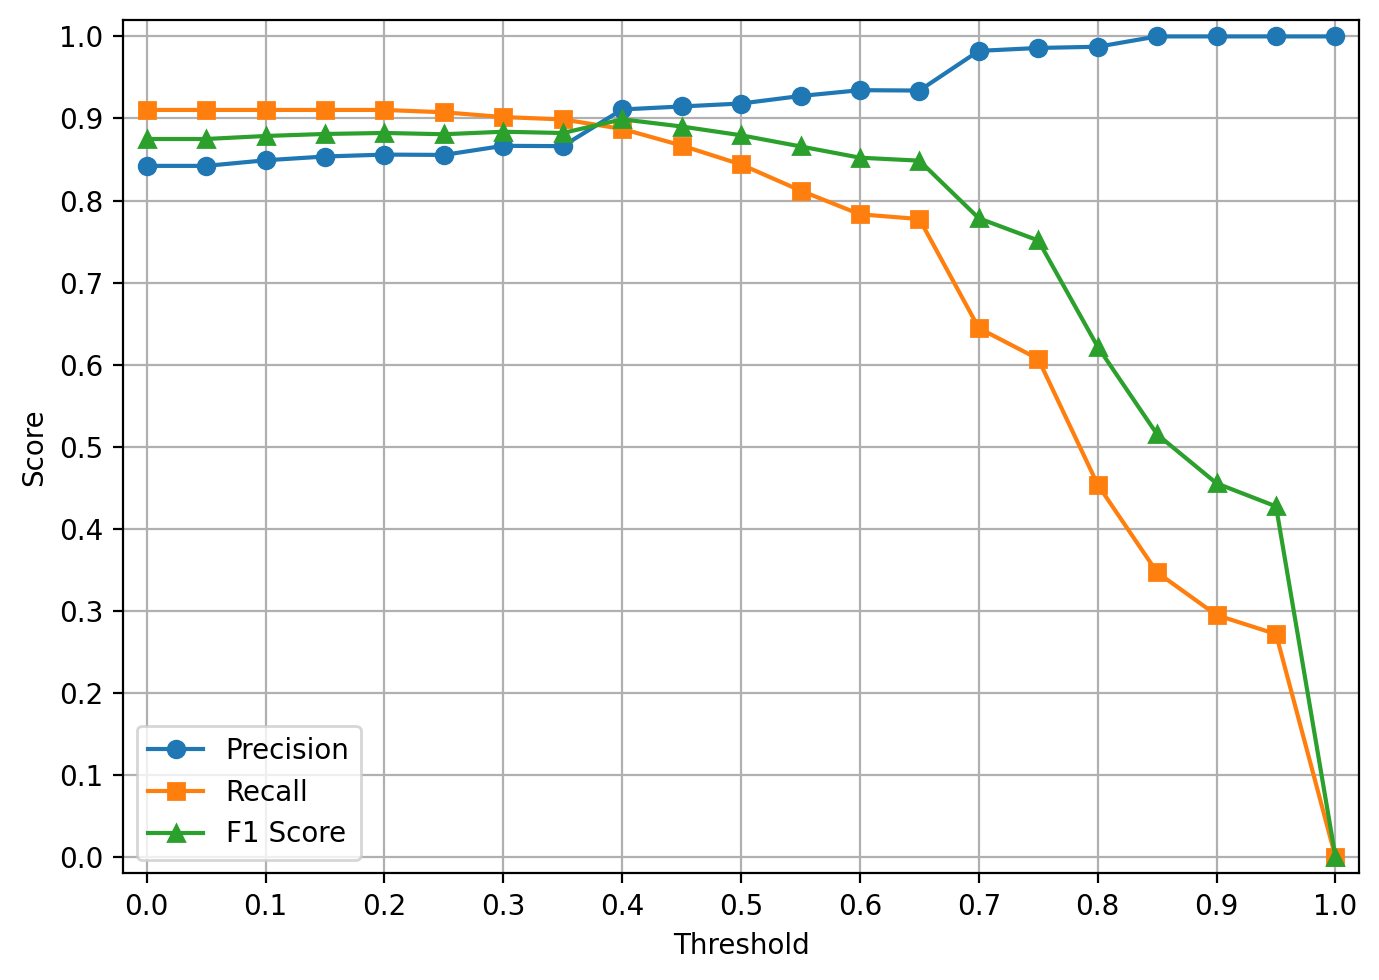

In [13]:
pr_curve("java", ["class_sim", "method_sim", "arg_sim"], [0.4, 0.3, 0.3])